# Imbalancing comes into realization when data is Baised to one of the Ouputs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data=pd.read_csv('/home/hammadali08/Vidoes/CSV file/Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


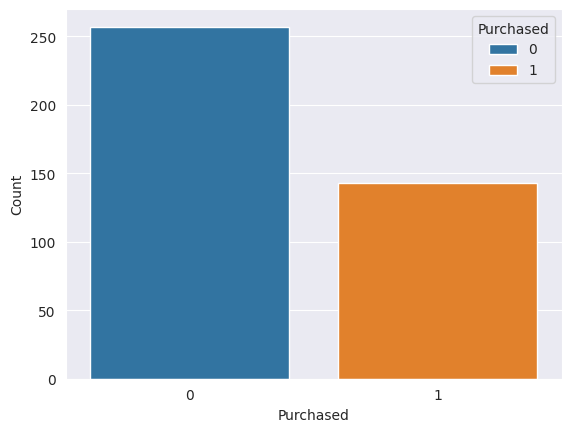

In [12]:
sns.countplot(data=data, x='Purchased',hue='Purchased')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()

In [13]:
data.drop(['User ID'],axis=1,inplace=True)

In [14]:
data.drop(['Gender'],axis=1,inplace=True)

In [15]:
data

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [16]:
x=data.iloc[:,:-1]
y=data['Purchased']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lg=LogisticRegression()

In [21]:
lg.fit(x_train,y_train)

LogisticRegression()

In [22]:
lg.score(x_test,y_test)

0.89

In [24]:
lg.predict([[32,150000]])

/home/hammadali08/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

# Now will try this dataset with IMBALACE
Under Sampling: which makes a baised output equals to Lesser Output by decreasing the values of Baised output
Over Sampling: Which increases lesser Output and made it equal to Baised Output

In [26]:
data['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [27]:
from imblearn.under_sampling import RandomUnderSampler
ru=RandomUnderSampler()

In [33]:
ru_x,ru_y=ru.fit_resample(x,y)

231    0
228    0
161    0
82     0
377    0
      ..
393    1
395    1
396    1
397    1
399    1
Name: Purchased, Length: 286, dtype: int64

In [34]:
ru_y.value_counts()

Purchased
0    143
1    143
Name: count, dtype: int64

In [35]:
ru_x_train,ru_x_test,ru_y_train,ru_y_test=train_test_split(ru_x,ru_y,test_size=0.25,random_state=0)

In [36]:
lg.fit(ru_x_train,ru_y_train)

LogisticRegression()

In [37]:
lg.score(ru_x_test,ru_y_test)

0.7638888888888888

In [38]:
from imblearn.over_sampling import RandomOverSampler

In [39]:
ros=RandomOverSampler()

In [40]:
ros_x,ros_y=ros.fit_resample(x,y)

In [41]:
ros_x_train,ros_x_test,ros_y_train,ros_y_test=train_test_split(ros_x,ros_y,test_size=0.25,random_state=0)

In [42]:
lg.fit(ros_x_train,ros_y_train)

LogisticRegression()

In [43]:
lg.score(ros_x_test,ros_y_test)

0.8449612403100775

In [44]:
ros_y.value_counts()

Purchased
0    257
1    257
Name: count, dtype: int64